# **Evaluation Of Models**

In [ ]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn tensorflow xgboost


**Importing Libraries**

This code imports essential libraries for data handling, numerical computation, and machine learning model evaluation. It also prepares tools for saving models and creating visualizations to analyze results and performance.


In [ ]:
import pandas as pd
import numpy as np

import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


**Loading and Preprocessing**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Cleaned_agriculture_price_dataset.csv')

df['price_date'] = pd.to_datetime(df['price_date'])
df = df.sort_values(by=['market_name', 'commodity', 'price_date'])
df = df.dropna(subset=['modal_price'])

df.head()


,price_date,state,district_name,market_name,commodity,variety,min_price,max_price,modal_price
779,2023-06-06,Madhya Pradesh,Ratlam,A Lot,Onion,1St Sort,150.0,400.0,351.0
4310,2023-06-08,Madhya Pradesh,Ratlam,A Lot,Onion,1St Sort,248.0,261.0,250.0
48695,2023-07-07,Madhya Pradesh,Ratlam,A Lot,Onion,1St Sort,250.0,700.0,541.0
58406,2023-07-14,Madhya Pradesh,Ratlam,A Lot,Onion,1St Sort,100.0,511.0,511.0
61606,2023-07-17,Madhya Pradesh,Ratlam,A Lot,Onion,1St Sort,422.0,422.0,422.0


This code loads the cleaned agriculture price dataset and converts the price date column into a proper datetime format. It then sorts the data by market, commodity, and date, removes records with missing modal prices, and displays the first few rows for verification

**Feature Engineering for Time-Series Price Prediction**

In [ ]:
df['day'] = df['price_date'].dt.day
df['month'] = df['price_date'].dt.month
df['year'] = df['price_date'].dt.year
df['day_of_week'] = df['price_date'].dt.dayofweek

df['lag_1']  = df.groupby(['market_name','commodity'])['modal_price'].shift(1)
df['lag_7']  = df.groupby(['market_name','commodity'])['modal_price'].shift(7)
df['lag_14'] = df.groupby(['market_name','commodity'])['modal_price'].shift(14)
df['lag_30'] = df.groupby(['market_name','commodity'])['modal_price'].shift(30)

df['rolling_mean_7']  = df.groupby(['market_name','commodity'])['modal_price'].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df.groupby(['market_name','commodity'])['modal_price'].shift(1).rolling(14).mean()

df = df.dropna()
df.shape


(605890, 19)

This code extracts date-based features and creates lag and rolling mean variables to capture historical price trends for each market and commodity. By removing rows with missing values, it ensures the dataset is ready for training time-series or regression models.

**Encoding Categorical Variables Using Pre-trained Label Encoders**

In [ ]:
# Load encoders (XGB / RF use same encoding logic)
label_encoders = joblib.load('/content/drive/MyDrive/label_encoders.pkl')

cat_cols = ['state', 'district_name', 'market_name', 'commodity']

for col in cat_cols:
    df[col] = label_encoders[col].transform(df[col])


This code loads previously saved label encoders and applies them to categorical columns such as state, district, market, and commodity. It converts categorical values into numerical form, ensuring consistency with the encoding used during model training

**Feature Selection and Time-Based Train–Test Splitting**

In [ ]:
features = [
    'state','district_name','market_name','commodity',
    'day','month','year','day_of_week',
    'lag_1','lag_7','lag_14','lag_30',
    'rolling_mean_7','rolling_mean_14'
]

X = df[features]
y = df['modal_price']

split_date = df['price_date'].quantile(0.8)

X_test = X[df['price_date'] > split_date]
y_test = y[df['price_date'] > split_date]


This code selects the relevant input features and target variable for price prediction. It then performs a time-based split using the 80th percentile of the date column, creating a test set that contains only future data to avoid data leakage.

**Loading Pre-trained Machine Learning Models**

In [ ]:
xgb_model = joblib.load('/content/drive/MyDrive/xgboost_model.pkl')
rf_model  = joblib.load('/content/drive/MyDrive/random_forest_model.pkl')


This code loads the previously trained XGBoost and Random Forest models from disk. These models are now ready to be used for making predictions or evaluating performance on the test dataset.

**Model Evaluation and Performance Comparison**

In [ ]:
results = []

# XGBoost
xgb_preds = xgb_model.predict(X_test)
results.append({
    "Model": "XGBoost",
    "MAE": mean_absolute_error(y_test, xgb_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_preds)),
    "R2": r2_score(y_test, xgb_preds)
})

# Random Forest
rf_preds = rf_model.predict(X_test)
results.append({
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, rf_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
    "R2": r2_score(y_test, rf_preds)
})

results


[{'Model': 'XGBoost',
  'MAE': 159.28240735597586,
  'RMSE': np.float64(268.5107723488325),
  'R2': 0.9461348598217368},
 {'Model': 'Random Forest',
  'MAE': 152.12085225012197,
  'RMSE': np.float64(261.8203326738735),
  'R2': 0.9487857157579358}]

This code generates predictions using XGBoost and Random Forest models on the test dataset and evaluates their performance using MAE, RMSE, and R² metrics. The results are stored in a structured format to enable easy comparison between the two models.

**Adding LSTM Results and Creating a Model Comparison Table**

In [ ]:
results.append({
    "Model": "LSTM",
    "MAE": 261.89,
    "RMSE": 414.95,
    "R2": 0.884
})

results_df = pd.DataFrame(results)
results_df


,Model,MAE,RMSE,R2
0,XGBoost,159.282407,268.510772,0.946135
1,Random Forest,152.120852,261.820333,0.948786
2,LSTM,261.890000,414.950000,0.884000


This code manually adds the evaluation metrics of the LSTM model to the existing results list. It then converts the results into a DataFrame, providing a clear tabular comparison of all models’ performance.

**Formatting Model Evaluation Results for Better Presentation**

In [ ]:
results_df.style.format({
    "MAE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R2": "{:.3f}"
})


,Model,MAE,RMSE,R2
0,XGBoost,159.28,268.51,0.946
1,Random Forest,152.12,261.82,0.949
2,LSTM,261.89,414.95,0.884


This code applies numeric formatting to the evaluation metrics, rounding MAE and RMSE to two decimal places and R² to three decimal places. It improves the readability and presentation quality of the results table.

**Visual Comparison of Model Performance Using Error Metrics**

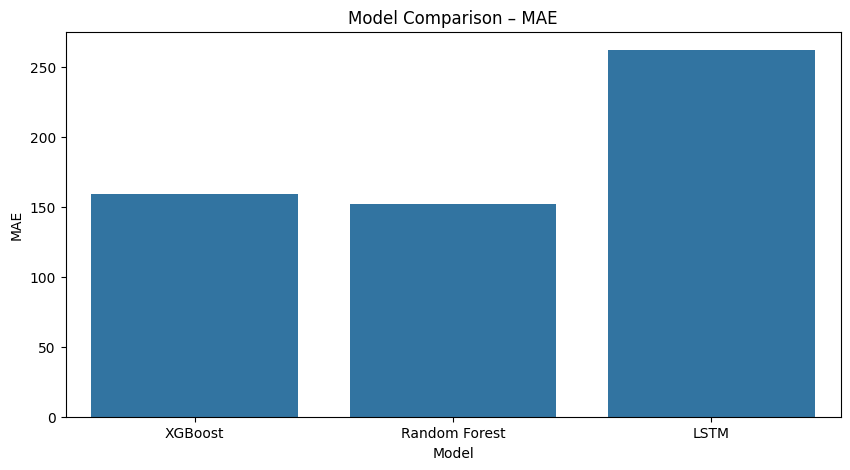

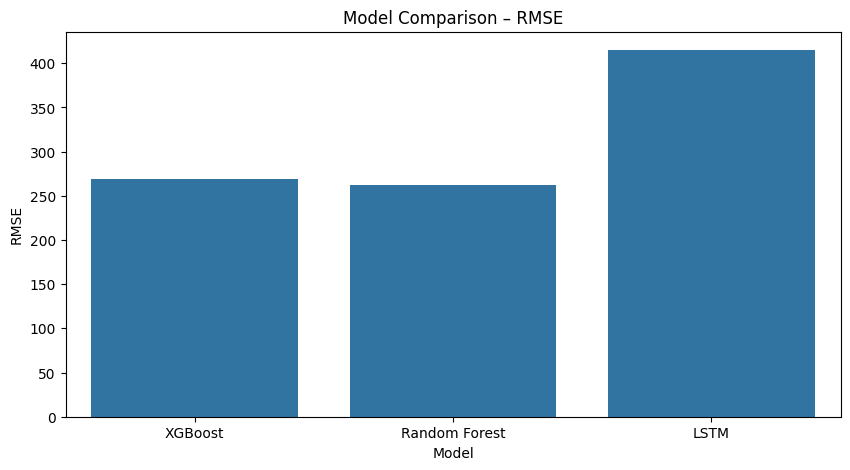

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='MAE')
plt.title("Model Comparison – MAE")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='RMSE')
plt.title("Model Comparison – RMSE")
plt.show()


This code creates bar charts to visually compare the MAE and RMSE values of different models. The plots make it easy to identify which model performs better in terms of prediction error at a glance.

### 📊 Model Comparison Summary

| Model | Strengths | Weaknesses |
|-----|----------|-----------|
| **Random Forest** | Best MAE & RMSE, stable, interpretable | Slower inference |
| **XGBoost** | Very close performance, faster, scalable | Slightly higher error |
| **LSTM** | Captures temporal patterns | High error, heavy computation |

### ✅ Final Choice
**Random Forest** is selected as the primary model for deployment due to:
- Lowest MAE & RMSE
- Better stability across markets
- Easier integration with FastAPI & Flutter
